In [ ]:
library(Seurat)
library(ggplot2)
library(dplyr)
library(tidyr)
library(forcats)
library(scales)
library(ggrepel)
library(patchwork)
library(UpSetR)
library(glue)

In [ ]:
## Build a local lean prostate-atlas reference for ProstateAtlasMapR

suppressPackageStartupMessages({
  if (!requireNamespace("devtools", quietly = TRUE)) {
    stop("Please install/load the r442 env that has devtools.")
  }
  if (!requireNamespace("Seurat", quietly = TRUE)) {
    stop("Seurat is required.")
  }
})

pkg_dir <- "/home/data/tanglei/project/prostate_altas/output/Rpackage/ProstateAtlasMapR"
qc_path <- "/home/data/tanglei/project/prostate_altas/output/04/QC_fin.qs"
save_path <- "/home/data/tanglei/project/prostate_altas/output/Rpackage/prostate_atlas_reference.qs"

devtools::load_all(pkg_dir, quiet = TRUE)

t0 <- Sys.time()

ref <- ProstateAtlasMapR::build_reference(
  qc_path = qc_path,
  reduction = "rpca",
  umap_reduction = "umap.rpca",
  npcs = 50,
  annotation_levels = c("H1", "H2", "H3"),
  keep_meta_cols = c("sample.ID", "GSE.ID"),  # optional; set NULL to keep only annotation cols
  save_path = save_path,
  verbose = TRUE
)

t1 <- Sys.time()

In [ ]:
## Sketch

suppressPackageStartupMessages({
  library(Seurat)
  library(future)
})

devtools::load_all(
  "/home/data/tanglei/project/prostate_altas/output/Rpackage/ProstateAtlasMapR",
  quiet = TRUE
)

## ---- paths ----
query_path <- "/home/data/tanglei/project/prostate_altas/output/06/Sketch_Integration_GSE.qs"
ref_path <- "/home/data/tanglei/project/prostate_altas/output/Rpackage/prostate_atlas_reference.qs"
out_dir <- "/home/data/tanglei/project/prostate_altas/output/09"
out_path <- file.path(out_dir, "sketch_RM.qs")
query_assay <- "sketch"
annotation_levels <- c("H2", "H3")

n_workers <- 8
plan("multisession", workers = n_workers)
options(future.globals.maxSize = Inf)

## ---- load reference ----
ref <- ProstateAtlasMapR::get_reference(path = ref_path)

## ---- load query ----
seu <- qs::qread(query_path)
seu[[query_assay]] <- JoinLayers(seu[[query_assay]])
DefaultAssay(seu) <- query_assay

## ---- prepare reference (drop cells with NA in H2 or H3) ----
ref_seu <- ref$seurat_obj
anno_cols <- paste0("celltype_manual_", annotation_levels)
keep <- Reduce(
  `&`,
  lapply(anno_cols, function(col) !is.na(ref_seu[[col]][, 1]))
)
n_drop <- sum(!keep)
if (n_drop > 0) {
  message("Excluding ", n_drop, " reference cell(s) with NA in ",
          paste(anno_cols, collapse = " / "))
  ref_seu <- subset(ref_seu, cells = colnames(ref_seu)[keep])
}

dims <- ref$npcs
k.anchor <- 5
k.score <- 30
k.weight <- 100

## ---- one FindTransferAnchors, transfer H2 + H3 together ----
t0 <- Sys.time()

anchors <- FindTransferAnchors(
  reference = ref_seu,
  query = seu,
  reference.assay = DefaultAssay(ref_seu),
  query.assay = query_assay,
  reference.reduction = ref$reduction,
  dims = seq_len(dims),
  normalization.method = "LogNormalize",
  k.anchor = k.anchor,
  k.score = k.score,
  verbose = TRUE
)

refdata <- stats::setNames(as.list(anno_cols), anno_cols)
umap_key <- Key(ref_seu[[ref$umap_reduction]])

seu <- MapQuery(
  anchorset = anchors,
  query = seu,
  reference = ref_seu,
  refdata = refdata,
  reference.reduction = ref$reduction,
  reduction.model = ref$umap_reduction,
  transferdata.args = list(k.weight = k.weight),
  projectumap.args = list(
    reduction.name = ref$umap_reduction,
    reduction.key = umap_key
  ),
  verbose = TRUE
)

t1 <- Sys.time()

## ---- save ----
qs::qsave(seu, out_path)

plan("sequential")


In [2]:
seu = qs::qread("/home/data/tanglei/project/prostate_altas/output/09/sketch_RM.qs")

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



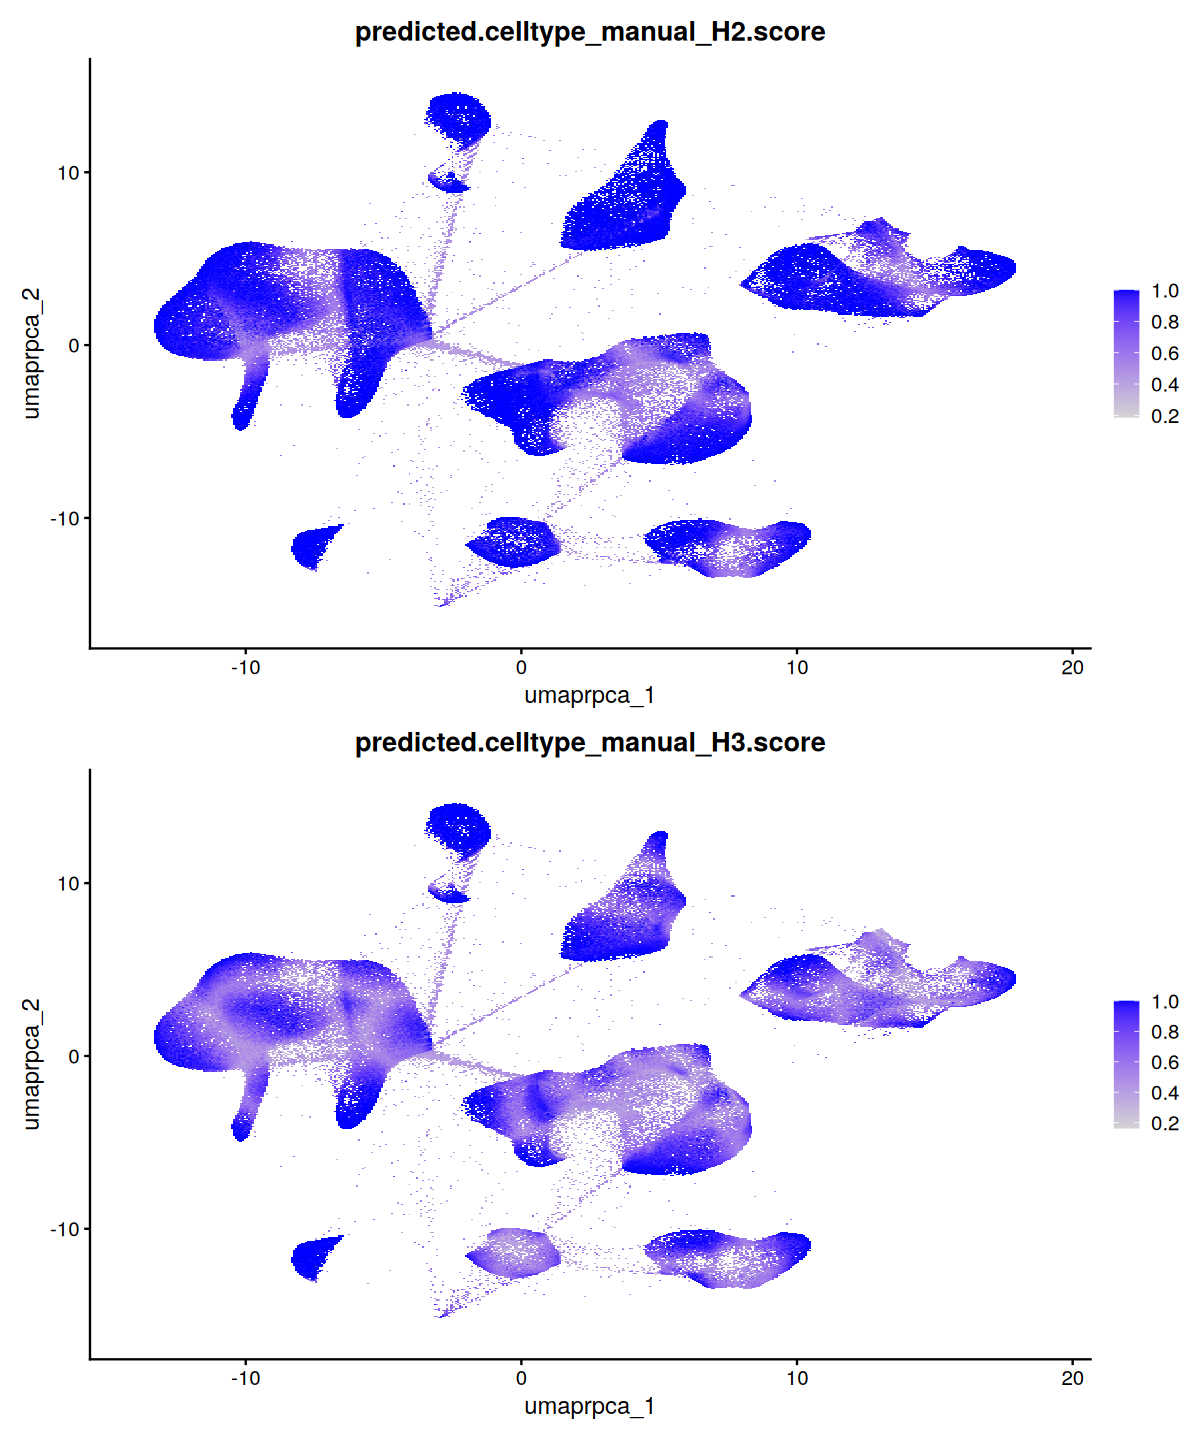

In [8]:
options(repr.plot.width = 10, repr.plot.height = 12)
FeaturePlot(
  seu,
  features = "predicted.celltype_manual_H2.score",
  reduction = "umap.rpca",
  label = FALSE
)+FeaturePlot(
  seu,
  features = "predicted.celltype_manual_H3.score",
  reduction = "umap.rpca",
  label = FALSE
)


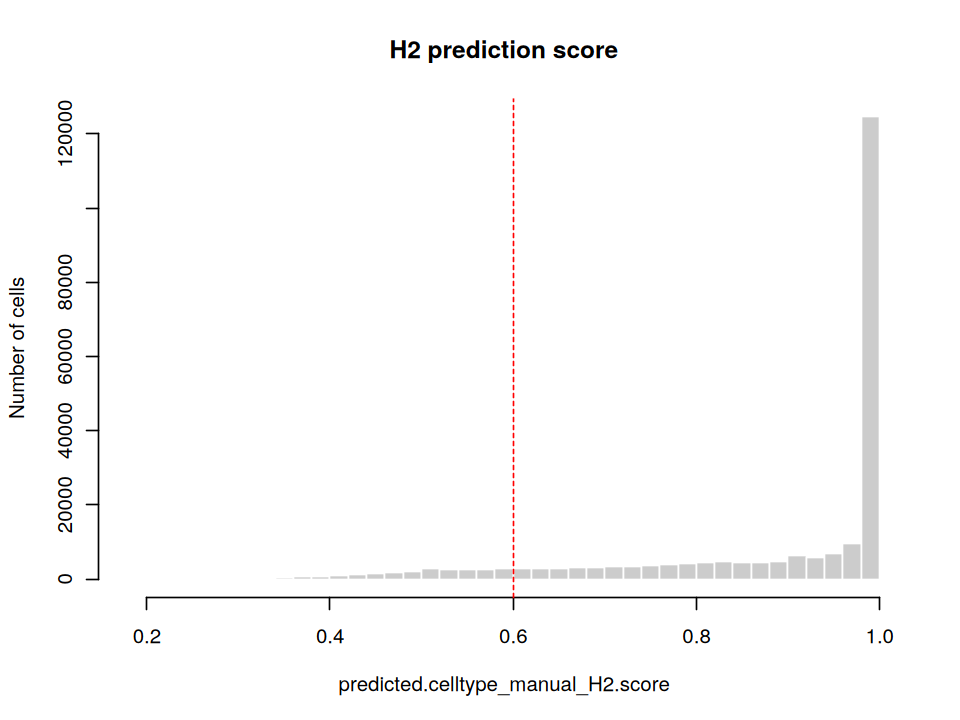

In [22]:
options(repr.plot.width = 8, repr.plot.height = 6)
hist(
  seu$predicted.celltype_manual_H2.score,
  breaks = 50,
  main = "H2 prediction score",
  xlab = "predicted.celltype_manual_H2.score",
  ylab = "Number of cells",
  col = "grey80",
  border = "white"
)
abline(v = 0.6, col = "red", lty = 2)

In [18]:
seu$predicted.celltype_manual_H2[seu$predicted.celltype_manual_H2.score < 0.6] = "Unknown"

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



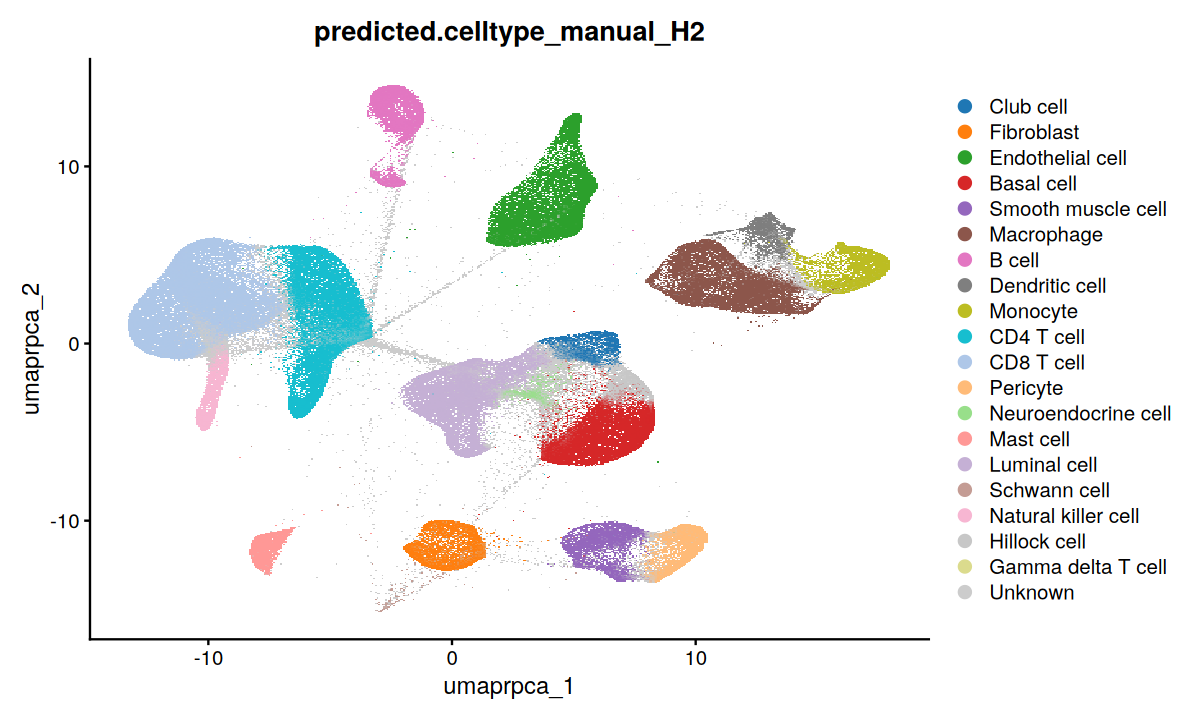

In [21]:
lab_col <- "predicted.celltype_manual_H2"  # 或上面的 _plot
labs <- unique(as.character(seu[[lab_col]][, 1]))
labs <- labs[!is.na(labs)]
labs_main <- setdiff(labs, "Unknown")

pal <- ggsci::pal_d3("category20")(length(labs_main))
names(pal) <- labs_main
pal["Unknown"] <- "grey80"

## 让 Unknown 图例靠后（可选）
seu[[lab_col]] <- factor(seu[[lab_col]][, 1], levels = c(labs_main, "Unknown"))

options(repr.plot.width = 10, repr.plot.height = 6)
DimPlot(
  seu,
  group.by = lab_col,
  reduction = "umap.rpca",
  label = FALSE
) + ggplot2::scale_color_manual(values = pal, na.value = "grey80")

In [23]:
seu$predicted.celltype_manual_H3[seu$predicted.celltype_manual_H2 == "Unknown"] = "Unknown"

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



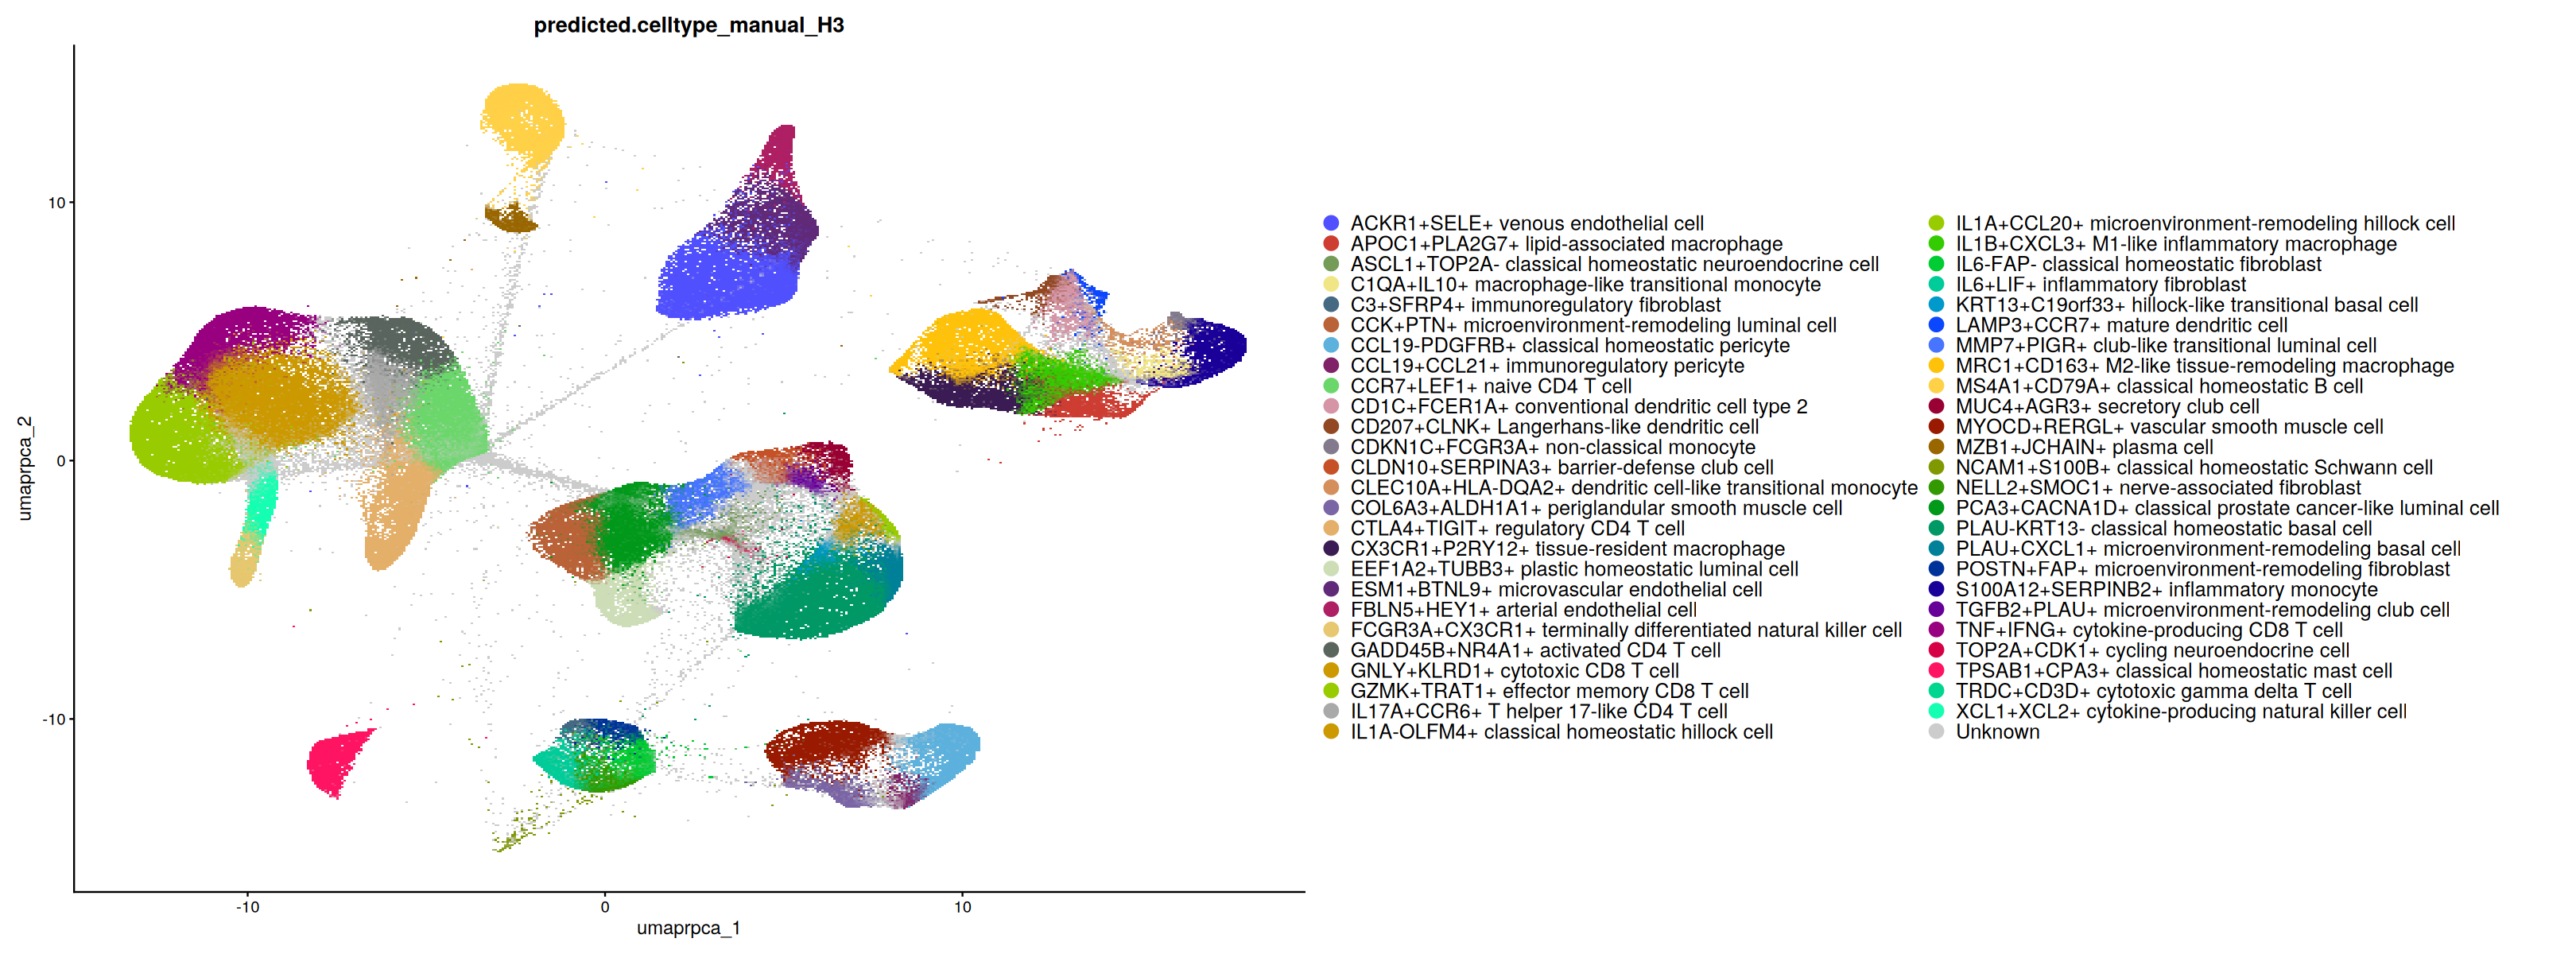

In [25]:
suppressPackageStartupMessages({
  library(Seurat)
  library(ggplot2)
  library(ggsci)
  library(cowplot)
})

plot_rm_dim <- function(seu, group_var, reduction = "umap.rpca") {
  labs <- as.character(seu[[group_var]][, 1])
  labs[is.na(labs)] <- "Unknown"
  types_main <- sort(setdiff(unique(labs), "Unknown"))
  n_main <- length(types_main)

  if (n_main <= 20) {
    cols_main <- setNames(pal_d3("category20")(max(n_main, 1))[seq_len(n_main)], types_main)
  } else {
    igv_base <- pal_igv("default")(51)
    cols_main <- setNames(colorRampPalette(igv_base)(n_main), types_main)
  }
  custom_cols <- c(cols_main, Unknown = "grey80")
  seu[[group_var]] <- factor(labs, levels = c(types_main, "Unknown"))

  legend_ncol <- if (n_main + 1L <= 30) 1 else 2
  legend_text_size <- if (legend_ncol == 1) 13 else 15
  legend_pt_size   <- if (legend_ncol == 1) 4 else 4.5
  rel_w <- if (legend_ncol == 1) c(1, 0.55) else c(1, 0.95)

  p_main <- DimPlot(seu, group.by = group_var, reduction = reduction, label = FALSE) +
    scale_color_manual(values = custom_cols, drop = FALSE) +
    ggtitle(group_var) +
    NoLegend()

  p_legend <- cowplot::get_legend(
    DimPlot(seu, group.by = group_var, reduction = reduction, label = FALSE) +
      scale_color_manual(values = custom_cols, drop = FALSE) +
      theme(
        legend.title = element_blank(),
        legend.text  = element_text(size = legend_text_size)
      ) +
      guides(color = guide_legend(
        ncol = legend_ncol,
        override.aes = list(size = legend_pt_size)
      ))
  )

  options(
    repr.plot.width  = if (legend_ncol == 1) 12 else 27,
    repr.plot.height = 10
  )
  cowplot::plot_grid(
    p_main, p_legend,
    ncol = 2, rel_widths = rel_w,
    align = "h", axis = "tb"
  )
}

plot_rm_dim(seu, "predicted.celltype_manual_H3")

In [ ]:
## GSE141445
library(Seurat)
library(data.table)
library(Matrix)
library(future)
raw_path <- "/home/data/tanglei/project/prostate_altas/data/test_GSE141445/GSM4203181_data.raw.matrix.txt.gz"
hdr <- scan(raw_path, what = character(), nlines = 1, sep = "\t", quiet = TRUE)
dt  <- fread(raw_path, skip = 1, header = FALSE)
genes <- as.character(dt[[1]])
mat <- as.matrix(dt[, -1])
storage.mode(mat) <- "numeric"
rownames(mat) <- make.unique(genes)
colnames(mat) <- hdr
rm(dt); gc()

In [31]:
mat <- Matrix(mat, sparse = TRUE)
seu <- CreateSeuratObject(
  counts = mat,
  project = "GSE141445",
  min.cells = 3,
  min.features = 200
)
rm(mat); gc()

Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”


,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,5059416,270.3,7465189,398.7,7465189,398.7
Vcells,3355756757,25602.4,6266004934,47805.9,6206870572,47354.7


In [32]:
seu$patient <- factor(
  sapply(strsplit(colnames(seu), "-"), tail, 1),
  levels = as.character(1:13)
)
seu$sample.ID <- paste0("P", seu$patient)
seu$GSE.ID <- "GSE141445"

seu <- NormalizeData(seu, verbose = FALSE)


   1    2    3    4    5    6    7    8    9   10   11   12   13 
1554 5302 4982 4077 1339 1586 1534 3032 2458  679 2824 5780 1277 


In [ ]:
## ---- Reference mapping ----
devtools::load_all(
  "/home/data/tanglei/project/prostate_altas/output/Rpackage/ProstateAtlasMapR",
  quiet = TRUE
)
ref <- ProstateAtlasMapR::get_reference(
  path = "/home/data/tanglei/project/prostate_altas/output/Rpackage/prostate_atlas_reference.qs"
)
plan("multisession", workers = 8)
options(future.globals.maxSize = Inf)
## H2
seu <- map_query(
  reference = ref,
  query = seu,
  annotation_level = "H2",
  query_assay = "RNA",
  verbose = TRUE
)
## H3（同一对象上再迁一层）
seu <- map_query(
  reference = ref,
  query = seu,
  annotation_level = "H3",
  query_assay = "RNA",
  verbose = TRUE
)
plan("sequential")

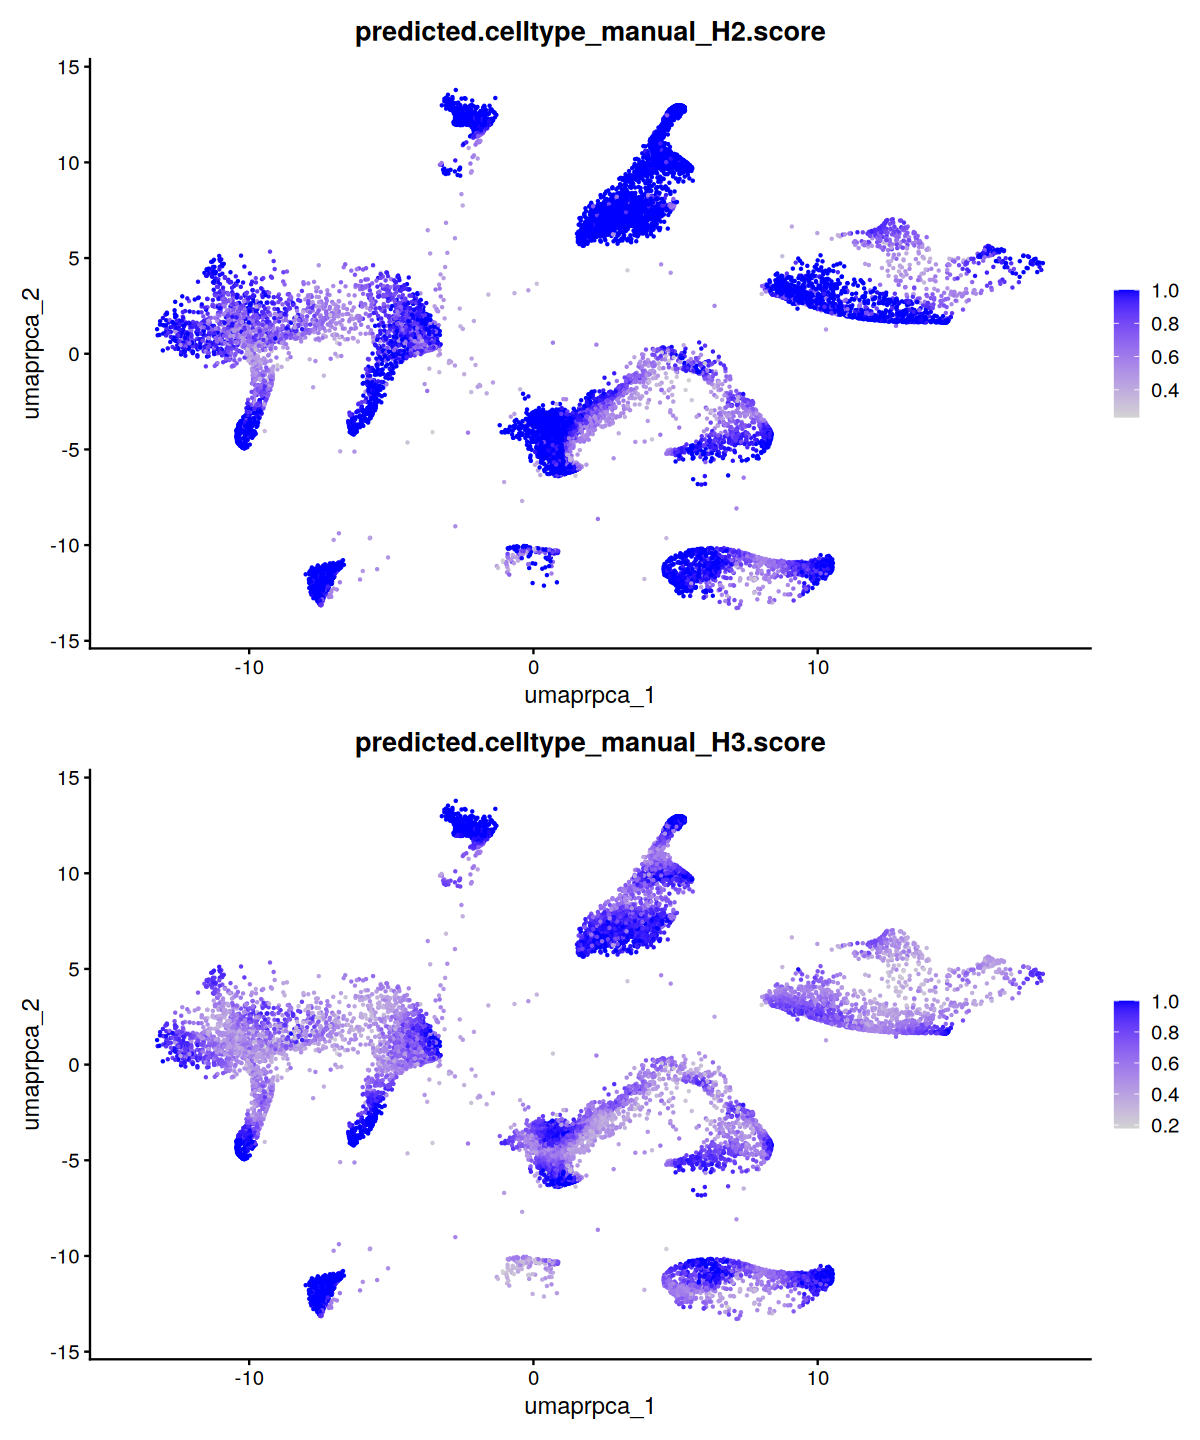

In [36]:
options(repr.plot.width = 10, repr.plot.height = 12)
FeaturePlot(
  seu,
  features = "predicted.celltype_manual_H2.score",
  reduction = "umap.rpca",
  label = FALSE
)+FeaturePlot(
  seu,
  features = "predicted.celltype_manual_H3.score",
  reduction = "umap.rpca",
  label = FALSE
)


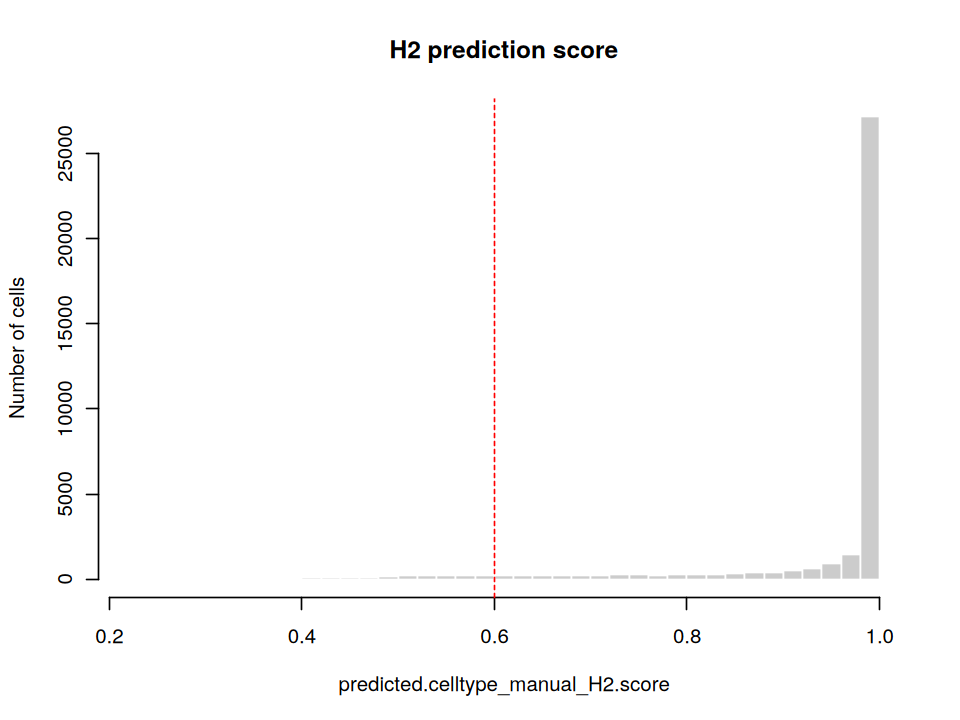

In [37]:
options(repr.plot.width = 8, repr.plot.height = 6)
hist(
  seu$predicted.celltype_manual_H2.score,
  breaks = 50,
  main = "H2 prediction score",
  xlab = "predicted.celltype_manual_H2.score",
  ylab = "Number of cells",
  col = "grey80",
  border = "white"
)
abline(v = 0.6, col = "red", lty = 2)

In [38]:
seu$predicted.celltype_manual_H2[seu$predicted.celltype_manual_H2.score < 0.6] = "Unknown"

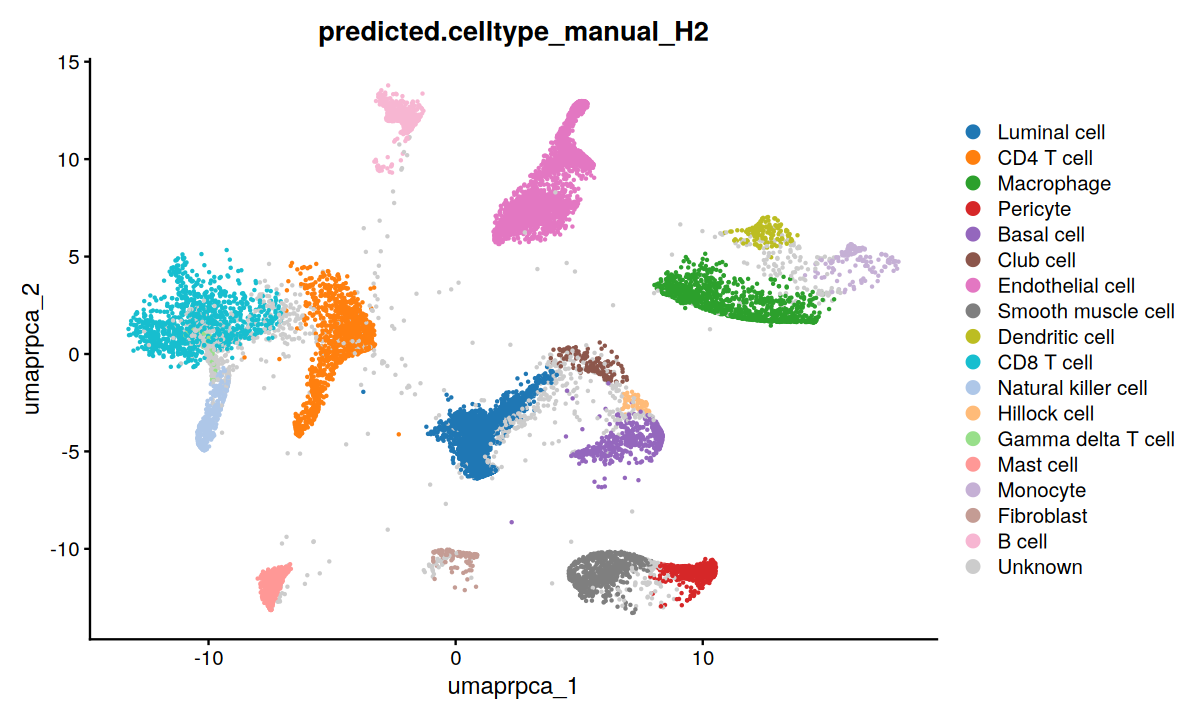

In [39]:
lab_col <- "predicted.celltype_manual_H2"  # 或上面的 _plot
labs <- unique(as.character(seu[[lab_col]][, 1]))
labs <- labs[!is.na(labs)]
labs_main <- setdiff(labs, "Unknown")

pal <- ggsci::pal_d3("category20")(length(labs_main))
names(pal) <- labs_main
pal["Unknown"] <- "grey80"

## 让 Unknown 图例靠后（可选）
seu[[lab_col]] <- factor(seu[[lab_col]][, 1], levels = c(labs_main, "Unknown"))

options(repr.plot.width = 10, repr.plot.height = 6)
DimPlot(
  seu,
  group.by = lab_col,
  reduction = "umap.rpca",
  label = FALSE
) + ggplot2::scale_color_manual(values = pal, na.value = "grey80")

In [40]:
seu$predicted.celltype_manual_H3[seu$predicted.celltype_manual_H2 == "Unknown"] = "Unknown"

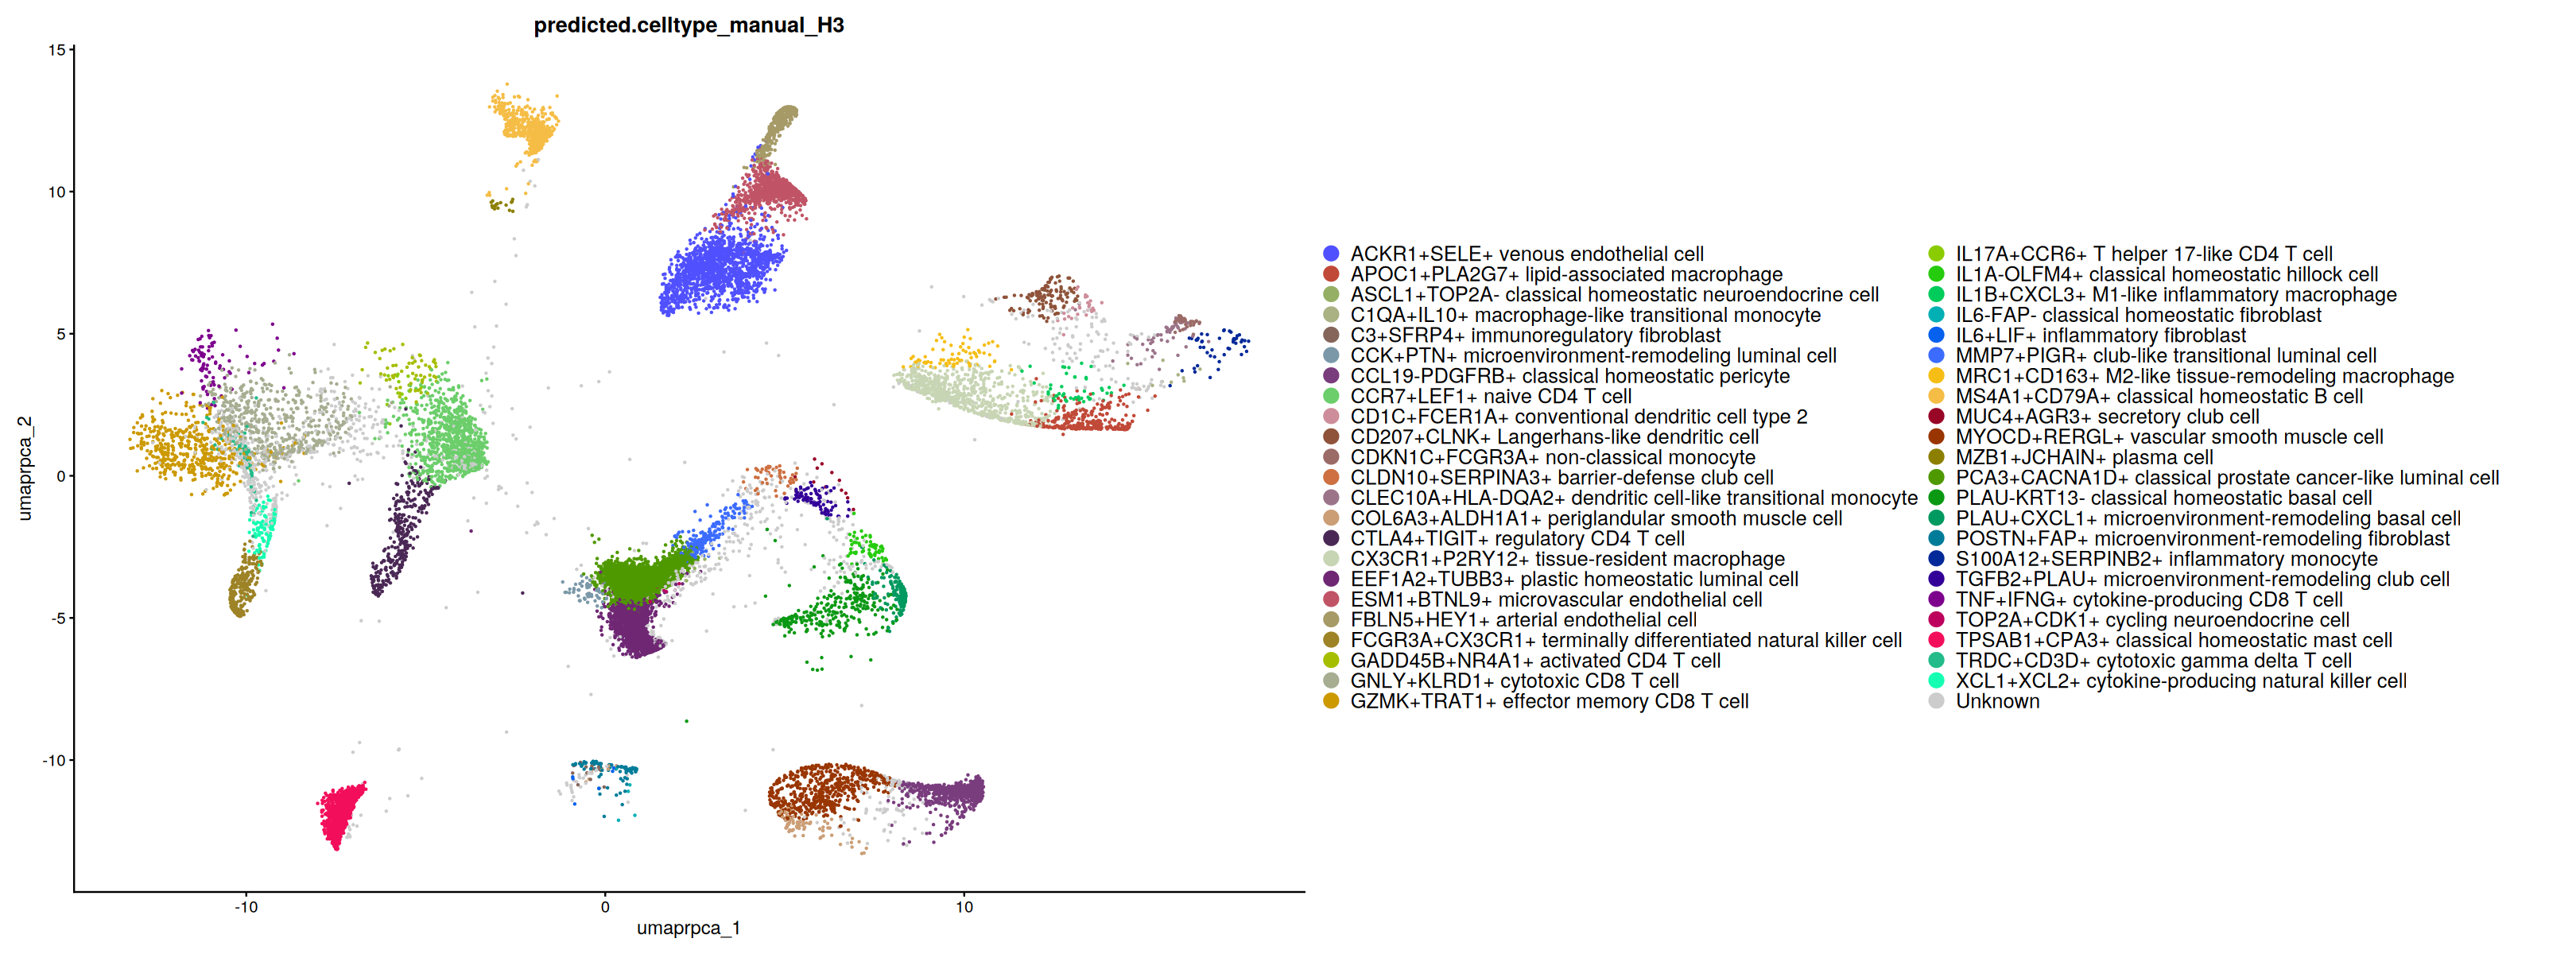

In [41]:
suppressPackageStartupMessages({
  library(Seurat)
  library(ggplot2)
  library(ggsci)
  library(cowplot)
})

plot_rm_dim <- function(seu, group_var, reduction = "umap.rpca") {
  labs <- as.character(seu[[group_var]][, 1])
  labs[is.na(labs)] <- "Unknown"
  types_main <- sort(setdiff(unique(labs), "Unknown"))
  n_main <- length(types_main)

  if (n_main <= 20) {
    cols_main <- setNames(pal_d3("category20")(max(n_main, 1))[seq_len(n_main)], types_main)
  } else {
    igv_base <- pal_igv("default")(51)
    cols_main <- setNames(colorRampPalette(igv_base)(n_main), types_main)
  }
  custom_cols <- c(cols_main, Unknown = "grey80")
  seu[[group_var]] <- factor(labs, levels = c(types_main, "Unknown"))

  legend_ncol <- if (n_main + 1L <= 30) 1 else 2
  legend_text_size <- if (legend_ncol == 1) 13 else 15
  legend_pt_size   <- if (legend_ncol == 1) 4 else 4.5
  rel_w <- if (legend_ncol == 1) c(1, 0.55) else c(1, 0.95)

  p_main <- DimPlot(seu, group.by = group_var, reduction = reduction, label = FALSE) +
    scale_color_manual(values = custom_cols, drop = FALSE) +
    ggtitle(group_var) +
    NoLegend()

  p_legend <- cowplot::get_legend(
    DimPlot(seu, group.by = group_var, reduction = reduction, label = FALSE) +
      scale_color_manual(values = custom_cols, drop = FALSE) +
      theme(
        legend.title = element_blank(),
        legend.text  = element_text(size = legend_text_size)
      ) +
      guides(color = guide_legend(
        ncol = legend_ncol,
        override.aes = list(size = legend_pt_size)
      ))
  )

  options(
    repr.plot.width  = if (legend_ncol == 1) 12 else 27,
    repr.plot.height = 10
  )
  cowplot::plot_grid(
    p_main, p_legend,
    ncol = 2, rel_widths = rel_w,
    align = "h", axis = "tb"
  )
}

plot_rm_dim(seu, "predicted.celltype_manual_H3")

In [ ]:
qs::qsave(seu,"/home/data/tanglei/project/prostate_altas/output/09/GSE141445_RM.qs")

: 